# Cars24 Used Car Price - Exploratory Data Analysis

Dataset: `cars24-car-price-cleaned-new.csv` — already cleaned/encoded used-car listings.
Target: `selling_price` (in INR lakhs).

This notebook explores distributions, relationships, and data quality issues that
inform the preprocessing decisions used in `src/preprocessing.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../cars24-car-price-cleaned-new.csv')
df.shape

(19820, 17)

## 1. First look

In [2]:
df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19820 entries, 0 to 19819
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   selling_price     19820 non-null  float64
 1   km_driven         19820 non-null  int64  
 2   mileage           19820 non-null  float64
 3   engine            19820 non-null  float64
 4   max_power         19820 non-null  float64
 5   age               19820 non-null  float64
 6   make              19820 non-null  str    
 7   model             19820 non-null  str    
 8   Individual        19820 non-null  int64  
 9   Trustmark Dealer  19820 non-null  int64  
 10  Diesel            19820 non-null  int64  
 11  Electric          19820 non-null  int64  
 12  LPG               19820 non-null  int64  
 13  Petrol            19820 non-null  int64  
 14  Manual            19820 non-null  int64  
 15  5                 19820 non-null  int64  
 16  >5                19820 non-null  int64  
dtypes: f

In [4]:
df.isnull().sum().to_frame('missing_values')

,missing_values
selling_price,0
km_driven,0
mileage,0
engine,0
max_power,0
age,0
make,0
model,0
Individual,0
Trustmark Dealer,0


No missing values. Columns `Individual`/`Trustmark Dealer`, `Diesel`/`Electric`/`LPG`/`Petrol`, `Manual`, and `5`/`>5` are one-hot dummies for seller type, fuel type, transmission, and seat count respectively (each with one baseline category dropped).

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
selling_price,19820.0,6.585509,4.847364,0.3,3.41,5.2,7.85,2.090250e+01
km_driven,19820.0,58158.555348,51715.628176,100.0,31000.00,52000.0,74000.00,3.800000e+06
mileage,19820.0,19.503402,4.297784,4.0,16.95,19.3,22.32,1.200000e+02
engine,19820.0,1475.702381,518.571223,0.0,1197.00,1248.0,1582.00,6.752000e+03
max_power,19820.0,98.122907,44.761727,5.0,73.90,86.8,112.00,6.260000e+02
age,19820.0,8.438547,3.196636,2.0,6.00,8.0,10.00,3.100000e+01
Individual,19820.0,0.390666,0.487912,0.0,0.00,0.0,1.00,1.000000e+00
Trustmark Dealer,19820.0,0.009586,0.097442,0.0,0.00,0.0,0.00,1.000000e+00
Diesel,19820.0,0.492583,0.499958,0.0,0.00,0.0,1.00,1.000000e+00
Electric,19820.0,0.000404,0.020087,0.0,0.00,0.0,0.00,1.000000e+00


## 2. Target variable: `selling_price`

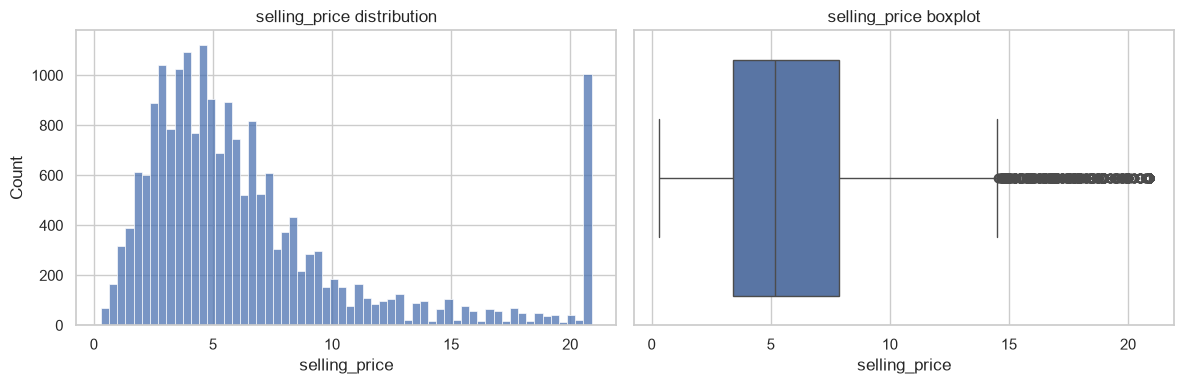

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['selling_price'], bins=60, ax=axes[0])
axes[0].set_title('selling_price distribution')
sns.boxplot(x=df['selling_price'], ax=axes[1])
axes[1].set_title('selling_price boxplot')
plt.tight_layout()
plt.show()

In [7]:
cap_value = df['selling_price'].max()
n_at_cap = (df['selling_price'] == cap_value).sum()
print(f"Max selling_price: {cap_value}")
print(f"Rows at the max value: {n_at_cap} ({n_at_cap / len(df):.1%} of data)")

Max selling_price: 20.90249999999996
Rows at the max value: 991 (5.0% of data)


**Data quality note:** the target is right-censored — it looks like prices were capped/clipped at ~20.9 lakhs during data collection. Almost 5% of rows sit exactly at this ceiling, dominated by luxury makes (Ferrari, Lamborghini, Rolls-Royce, Bentley, Mercedes-AMG, Maserati, Lexus all average exactly the cap). This means the model structurally cannot learn true prices above the cap and will underpredict high-end cars. We keep this in mind but do not attempt to fix it (no way to recover the true values).

In [8]:
df.groupby('make')['selling_price'].mean().sort_values(ascending=False).head(10)

make
BENTLEY         20.902500
FERRARI         20.902500
LEXUS           20.902500
MASERATI        20.902500
ROLLS-ROYCE     20.902500
LAMBORGHINI     20.902500
MERCEDES-AMG    20.902500
PORSCHE         20.866400
LAND            20.560147
JAGUAR          20.187500
Name: selling_price, dtype: float64

A log1p transform of the target compresses the right skew and tends to help linear models; we compare with/without it during model experimentation.

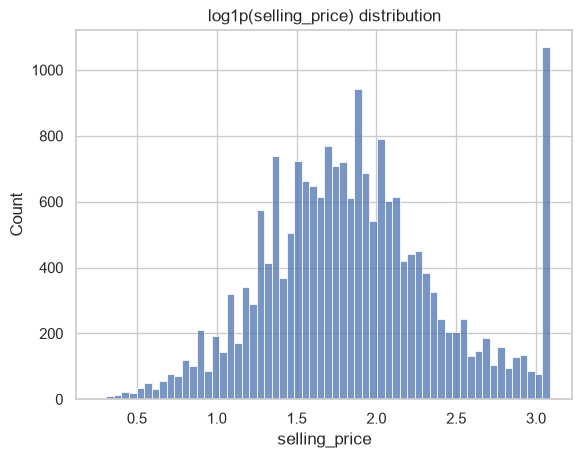

In [9]:
sns.histplot(np.log1p(df['selling_price']), bins=60)
plt.title('log1p(selling_price) distribution')
plt.show()

## 3. Numeric features

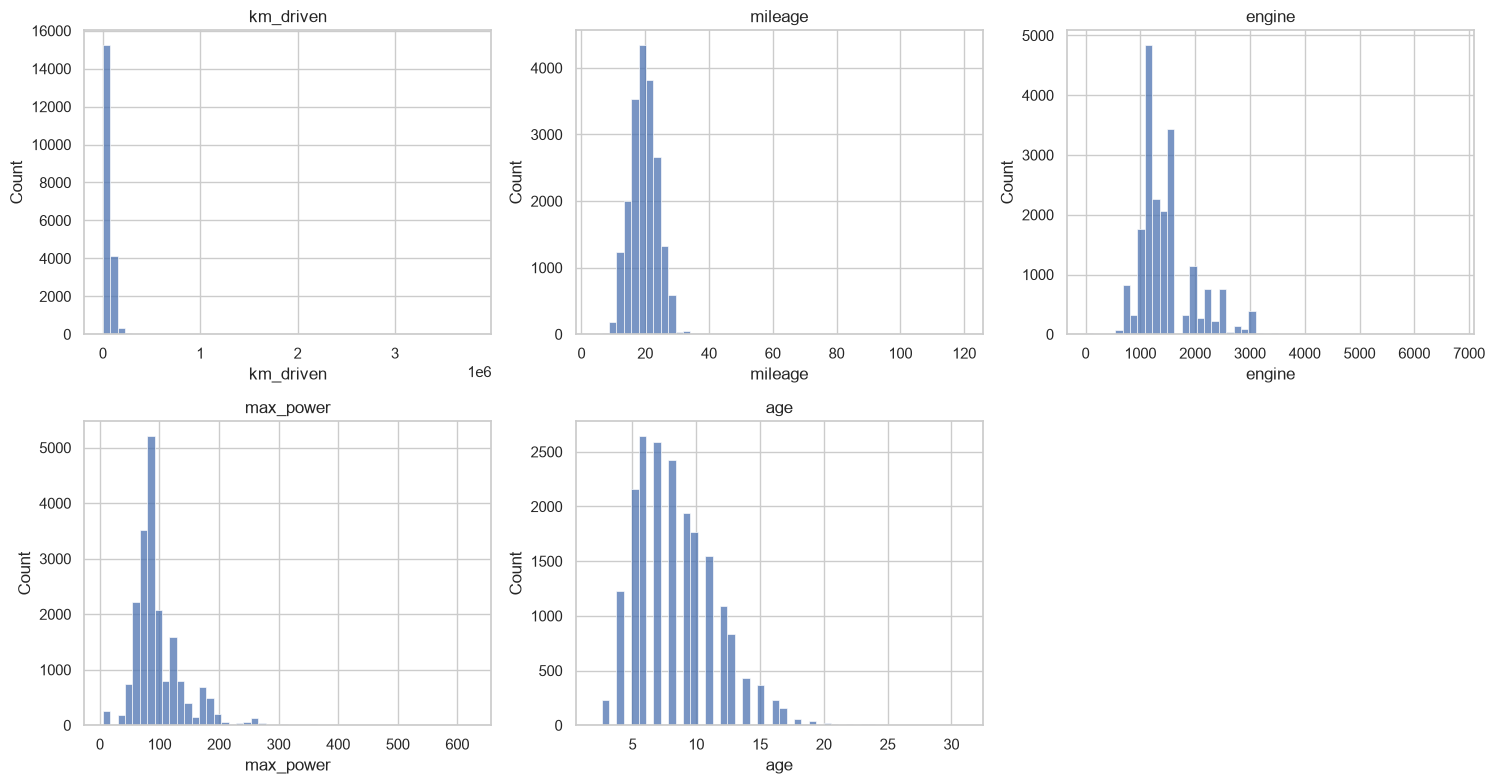

In [10]:
num_cols = ['km_driven', 'mileage', 'engine', 'max_power', 'age']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=50, ax=ax)
    ax.set_title(col)
axes[-1, -1].axis('off')
plt.tight_layout()
plt.show()

In [11]:
df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .999]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,99.9%,max
km_driven,19820.0,58158.555348,51715.628176,100.0,4500.00,10000.00,31000.00,52000.0,74000.00,120000.0,192000.0,479181.000,3800000.0
mileage,19820.0,19.503402,4.297784,4.0,10.91,12.90,16.95,19.3,22.32,26.0,28.4,33.540,120.0
engine,19820.0,1475.702381,518.571223,0.0,796.00,814.00,1197.00,1248.0,1582.00,2499.0,2993.0,4497.562,6752.0
max_power,19820.0,98.122907,44.761727,5.0,5.00,53.26,73.90,86.8,112.00,184.0,258.0,395.000,626.0
age,19820.0,8.438547,3.196636,2.0,3.00,4.00,6.00,8.0,10.00,14.0,17.0,23.181,31.0


**`km_driven` has extreme outliers** (max = 3.8M km, next highest ~1.48M) that are almost certainly data entry errors — no used car has driven millions of km. We winsorize/cap this feature at the 99th percentile in preprocessing rather than dropping rows, to avoid losing other useful signal in those records.

In [12]:
df['km_driven'].sort_values(ascending=False).head(10)

19818    3800000
17787    1485000
15331    1325000
11472     950000
15975     890000
5849      850000
8700      830000
13996     825000
14964     820000
4359      780000
Name: km_driven, dtype: int64

## 4. Correlation with target

In [13]:
corr = df.corr(numeric_only=True)['selling_price'].sort_values(ascending=False)
corr

selling_price       1.000000
max_power           0.770390
engine              0.652296
Diesel              0.335236
>5                  0.223282
Electric            0.019073
Trustmark Dealer   -0.019547
LPG                -0.053388
km_driven          -0.100739
Individual         -0.201808
5                  -0.234645
Petrol             -0.313570
mileage            -0.314927
age                -0.390667
Manual             -0.582019
Name: selling_price, dtype: float64

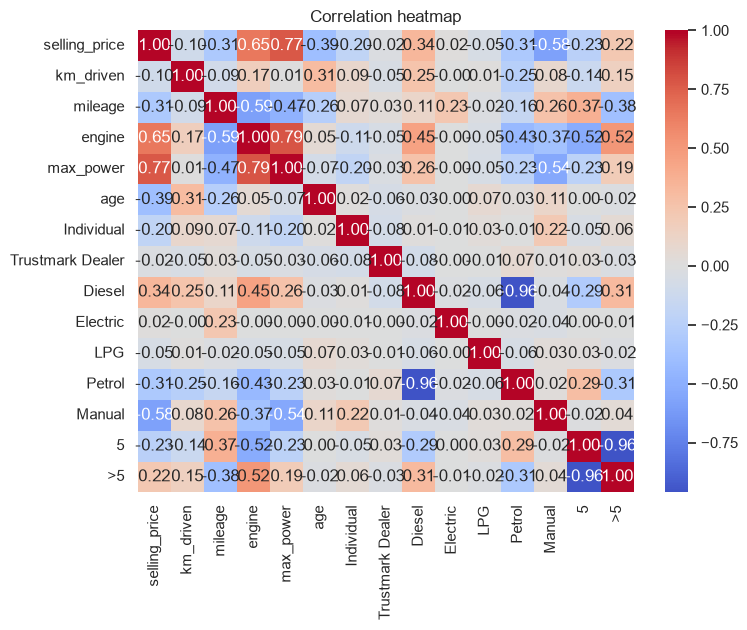

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation heatmap')
plt.show()

`max_power` and `engine` are the strongest positive drivers of price; `age` and `Manual` (manual transmission) are the strongest negative drivers — newer, automatic, higher-powered cars sell for more, as expected.

## 5. Categorical features: `make` / `model`

In [15]:
print('make: unique values =', df['make'].nunique())
print('model: unique values =', df['model'].nunique())
df['make'].value_counts().head(15)

make: unique values = 41
model: unique values = 3233


make
MARUTI           5650
HYUNDAI          3562
HONDA            1779
MAHINDRA         1276
TOYOTA           1189
TATA              971
FORD              900
VOLKSWAGEN        761
RENAULT           636
MERCEDES-BENZ     485
BMW               483
SKODA             422
CHEVROLET         406
AUDI              324
NISSAN            289
Name: count, dtype: int64

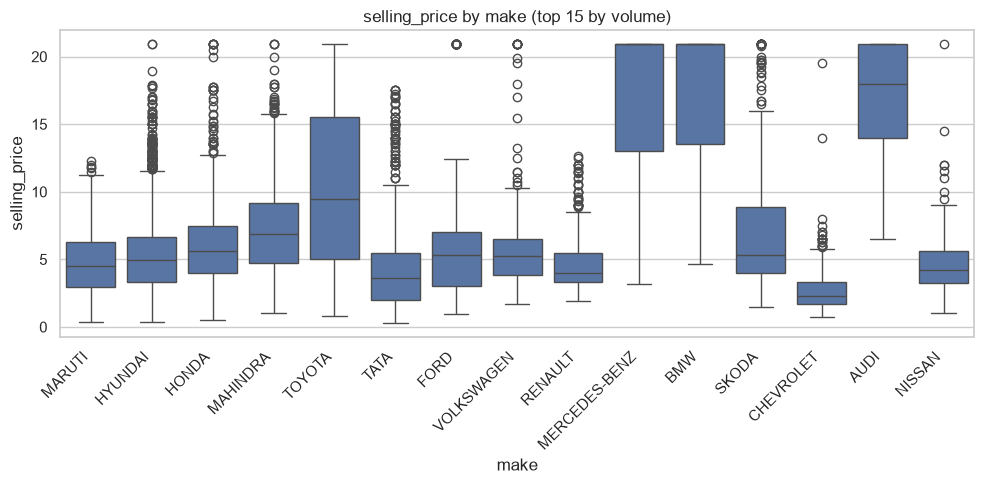

In [16]:
top_makes = df['make'].value_counts().head(15).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['make'].isin(top_makes)], x='make', y='selling_price', order=top_makes)
plt.xticks(rotation=45, ha='right')
plt.title('selling_price by make (top 15 by volume)')
plt.tight_layout()
plt.show()

`make` has 41 categories (one-hot friendly), but `model` has 3,233 unique values with a long tail of one-off listings — one-hot encoding it would explode dimensionality and overfit. We frequency-encode `model` instead (replace it with how common that model is in the training data), which keeps a useful, low-cardinality signal without leaking the target.

## 6. Bivariate relationships with numeric drivers

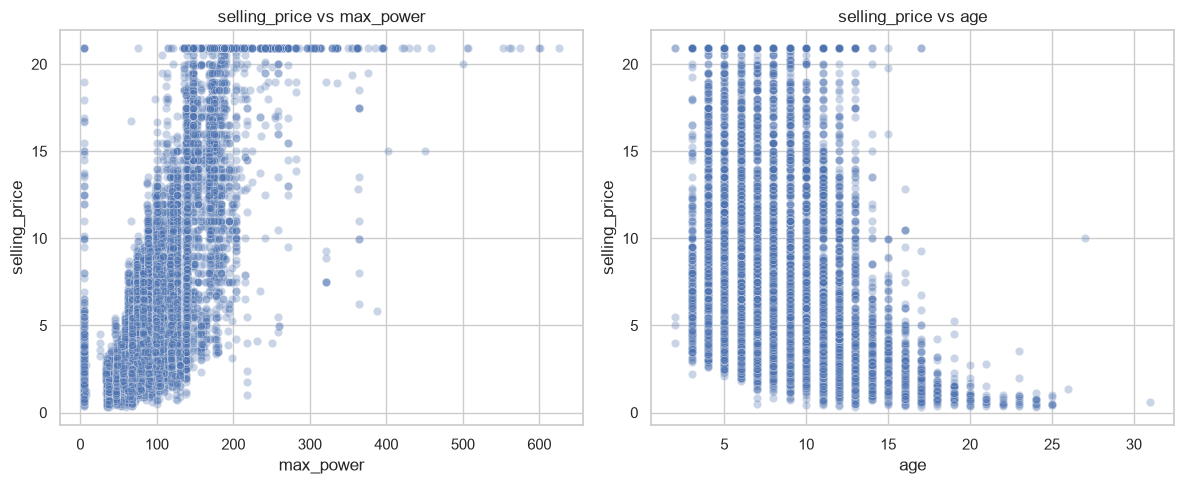

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='max_power', y='selling_price', alpha=0.3, ax=axes[0])
axes[0].set_title('selling_price vs max_power')
sns.scatterplot(data=df, x='age', y='selling_price', alpha=0.3, ax=axes[1])
axes[1].set_title('selling_price vs age')
plt.tight_layout()
plt.show()

## 7. Summary of preprocessing decisions carried into `src/preprocessing.py`

1. **`model`** → frequency-encoded (too high cardinality for one-hot).
2. **`make`** → one-hot encoded (41 categories, manageable).
3. **`km_driven`** → winsorized at the 99th percentile to tame data-entry-error outliers.
4. **Dummy columns** (seller/fuel/transmission/seats) → used as-is, already 0/1 encoded.
5. **Target (`selling_price`)** → modeled as-is; log1p transform evaluated as an option during experimentation, and its known right-censoring at ~20.9 lakhs is documented as a modeling limitation.
6. Numeric features are scaled for linear models; tree-based models use the raw (capped) values.